# Ejercicios Prácticos - Actividad 6

Al dataset seleccionado en la tarea de clasificación:
1. Eliminar la columna de las etiquetas de clases
2. Aplicar Hierarchical Clustering y K-MEANS
3. Mostrar métricas para evaluar la calidad
4. Gráficar el dataset original, los cluster datos por los algoritmos y comparar

In [4]:
from utils import *
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster.hierarchy import linkage
import pandas as pd
from scipy.cluster.hierarchy import dendrogram
from sklearn.preprocessing import LabelEncoder

Para Clasificación seleccione el Dataset de Mushrooms, pero investigue y para Clustering puede no ser tan representativo por la cantidad de feautures categoricas con las que cuenta.

Para este ejercicio utilizare el Dataset Wine descargado de UCI: 

https://archive.ics.uci.edu/dataset/109/wine


=== Hierarchical (Agglomerative, ward, k=3) ===
Silhouette:         0.2774  (↑ mejor)
Davies-Bouldin:     1.4186  (↓ mejor)
Calinski-Harabasz:  67.65   (↑ mejor)

=== K-Means (k=3, k-means++, n_init=10) ===
Silhouette:         0.2849  (↑ mejor)
Davies-Bouldin:     1.3892  (↓ mejor)
Calinski-Harabasz:  70.94   (↑ mejor)


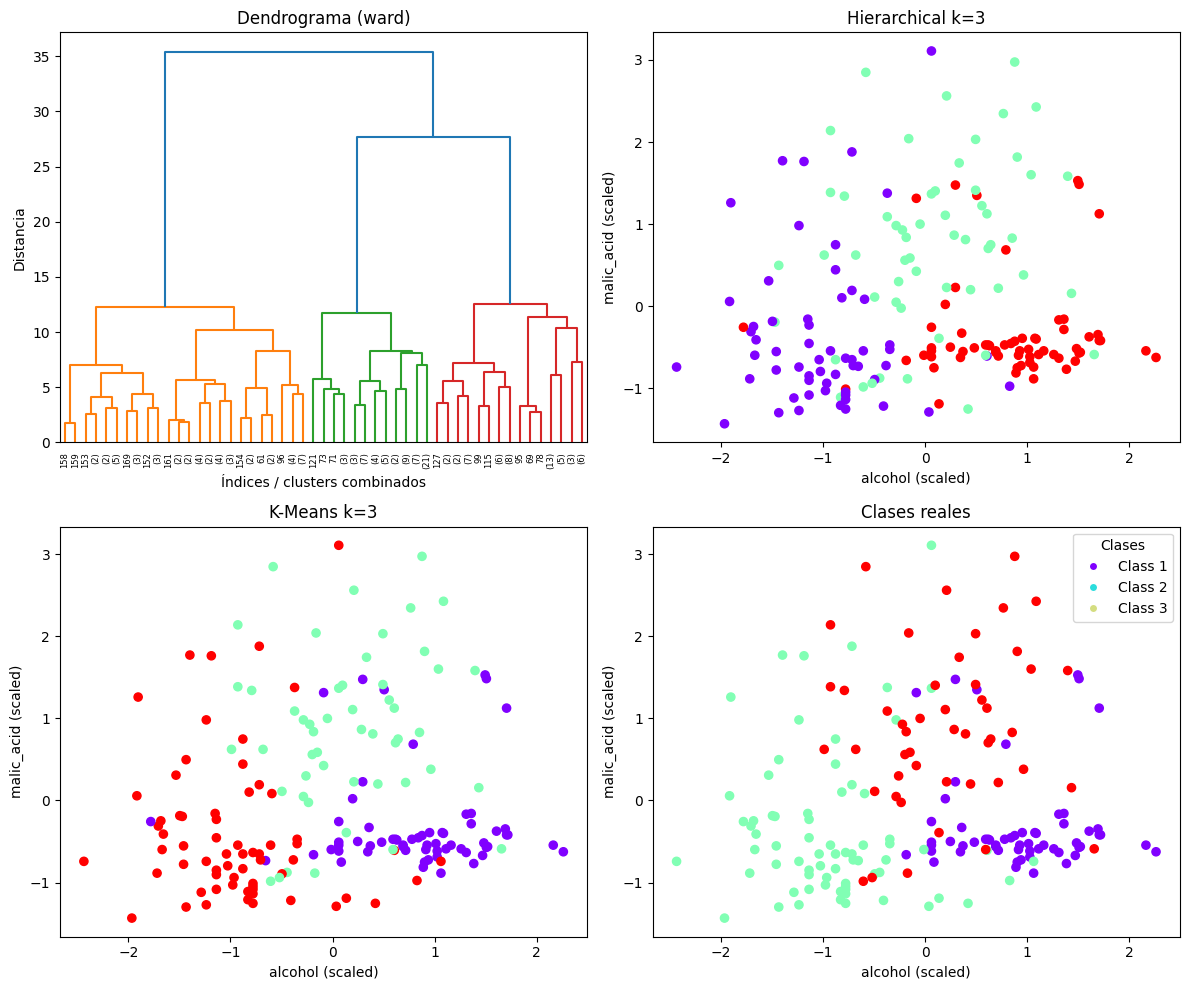

In [5]:
# SEMILLA para reproducibilidad
SEMILLA = 701

# 1) Cargar DataSet SIN etiquetas
column_names = [
    "class",
    "alcohol",
    "malic_acid",
    "ash",
    "alcalinity_of_ash",
    "magnesium",
    "total_phenols",
    "flavanoids",
    "nonflavanoid_phenols",
    "proanthocyanins",
    "color_intensity",
    "hue",
    "od280_od315",
    "proline"
]

df = pd.read_csv("wine.data", header=None, names=column_names)

# Separar etiquetas reales
y_true = df["class"].values - 1   # Restamos 1 para que sea 0,1,2
class_names = ["Class 1", "Class 2", "Class 3"]

X = df.drop(columns=["class"]).values
feature_names = df.drop(columns=["class"]).columns

# 2) Escalar
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

# Para visualizar en 2D

idx_a, idx_b = 0, 1
X2 = Xs[:, [idx_a, idx_b]]
xlab = f"{feature_names[idx_a]} (scaled)"
ylab = f"{feature_names[idx_b]} (scaled)"

# -------------------------
# A) Clustering Jerárquico
# -------------------------

Z = linkage(Xs, method="ward")
hier = AgglomerativeClustering(n_clusters=3, linkage="ward")   # Wine cuenta con 3 clases, es por eso que solo queremos 3 clusters
labels_h = hier.fit_predict(Xs)

evaluate_clustering(Xs, labels_h, name="Hierarchical (Agglomerative, ward, k=3)")

# -----------------
# B) K-Means
# -----------------

kmeans = KMeans(n_clusters=3, init="k-means++", n_init=10, random_state=SEMILLA)
labels_k = kmeans.fit_predict(Xs)

evaluate_clustering(Xs, labels_k, name="K-Means (k=3, k-means++, n_init=10)")

# -------------------------------------------------
# C) Visualización comparativa en un solo lienzo
# -------------------------------------------------
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# dendrograma

dendrogram(Z, truncate_mode="level", p=5, ax=axs[0, 0])
axs[0, 0].set_title("Dendrograma (ward)")
axs[0, 0].set_xlabel("Índices / clusters combinados")
axs[0, 0].set_ylabel("Distancia")

cmap = plt.cm.rainbow
norm = plt.Normalize(vmin=0, vmax=2)  # El valor maximo es 2 y el valor minimo es 0 

axs[0, 1].scatter(X2[:, 0], X2[:, 1], c=labels_h, s=35, cmap=cmap, norm=norm)
axs[0, 1].set_title("Hierarchical k=3")
axs[0, 1].set_xlabel(xlab)
axs[0, 1].set_ylabel(ylab)

# k-means (2D) con mismo esquema de colores
axs[1, 0].scatter(X2[:, 0], X2[:, 1], c=labels_k, s=35, cmap=cmap, norm=norm)
axs[1, 0].set_title("K-Means k=3")
axs[1, 0].set_xlabel(xlab)
axs[1, 0].set_ylabel(ylab)

# clases reales (2D) igual
axs[1, 1].scatter(X2[:, 0], X2[:, 1], c=y_true, s=35, cmap=cmap, norm=norm)
axs[1, 1].set_title("Clases reales")
axs[1, 1].set_xlabel(xlab)
axs[1, 1].set_ylabel(ylab)

if class_names is not None:
    handles = []
    for lbl in np.unique(y_true):
        handles.append(plt.Line2D([0], [0], marker="o", color="w",
                                  markerfacecolor=plt.cm.rainbow(lbl / len(class_names)),
                                  markersize=6))
    axs[1, 1].legend(handles, class_names, title="Clases", loc="best")

plt.tight_layout()
plt.show()


Tanto Hierarchical y K-Means muestran una estructura de clustering regular, no estan clasificando excelente ya que los valores en las métricas no son los optimos, sin embargo estan haciendo lo mejor que pueden jeje.

El dataset Wine es un dataset con clases solapadas como podemos ver en la figura de "Clases reales" y es por esto que no se logran clasificar del todo.

## Ejercicios Prácticos - Actividad 7

Al dataset seleccionado:
1. Aplicar PCA
2. Graficar
3. Calcular el error de reconstrucción y mostrar el valor.
4. A partir de los resultados obtenidos ¿mejora o empeora el conjunto de datos reconstruido?

## Implementación PCA

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from utils import reconstruction_error_mse

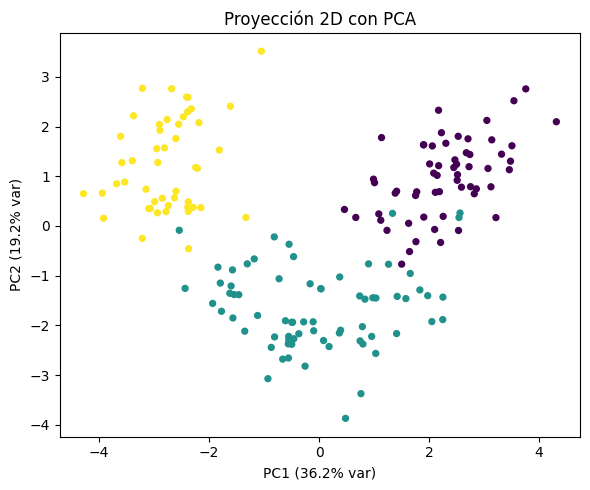

=== PCA Reconstrucción ===
Dimensión original: 13
Componentes usados para ~95% varianza: 10
Varianza explicada acumulada: 96.17%
Error de reconstrucción (MSE): 0.038303


In [7]:
SEMILLA = 701


# 1) Cargar dataset Wine
column_names = [
    "class",
    "alcohol",
    "malic_acid",
    "ash",
    "alcalinity_of_ash",
    "magnesium",
    "total_phenols",
    "flavanoids",
    "nonflavanoid_phenols",
    "proanthocyanins",
    "color_intensity",
    "hue",
    "od280_od315",
    "proline"
]

df = pd.read_csv("wine.data", header=None, names=column_names)

y = df["class"].values - 1
X = df.drop(columns=["class"]).values

# Escalado (importante para PCA)
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

# 2) Aplicar PCA
pca_2d = PCA(n_components=2, random_state=SEMILLA)
X_pca_2d = pca_2d.fit_transform(Xs)

pca_rec = PCA(n_components=0.95, random_state=SEMILLA)
X_pca_k = pca_rec.fit_transform(Xs)
X_reconstructed = pca_rec.inverse_transform(X_pca_k)

# 3) Graficar (proyección 2D)
plt.figure(figsize=(6, 5))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, s=18)
plt.title("Proyección 2D con PCA")
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var)")
plt.tight_layout()
plt.show()

# 4) Calcular y mostrar error de reconstrucción
mse = reconstruction_error_mse(Xs, X_reconstructed)
print("=== PCA Reconstrucción ===")
print(f"Dimensión original: {Xs.shape[1]}")
print(f"Componentes usados para ~95% varianza: {pca_rec.n_components_}")
print(f"Varianza explicada acumulada: {np.sum(pca_rec.explained_variance_ratio_)*100:.2f}%")
print(f"Error de reconstrucción (MSE): {mse:.6f}")

Al aplicar PCA en el gráfico mostrado se ve claramente una mejor separación entre las clases, entre la clase 2 y 3 aún hay un poco de mezcla, pero es muy ligera comparada con los métodos usados anteriormente.

Repondiendo a la pregunta, A partir de los resultados obtenidos ¿mejora o empeora el conjunto de datos reconstruido?
Desde mi punto de vista los datos mejoran en comparación con los métodos anteriores, la realidad es que de 13 columnas del dataset, se redujo a 10, y se logro construir el 96.17% de los datos, solo se perdió el 3.83%, creo que es un porcentaje muy pequeño y aceptable.

El error de reconstrucción MSE es muy pequeño.

Creo que solo se pudieron reducir 3 dimensiones ya que todas estan altamente relacionadas por la naturaleza del dataset, sin embargo obtuvimos buenos resultados.